In [3]:
# Channel W1 (Comparison of number of Traces (N) vs the sequence length (n))
# Author: Jaswanthi Mandalapu
# Date: 07 Apr 2026

import numpy as np
import matplotlib.pyplot as plt

n = 10
# X ~ i.i.d. Bernoulli(1/2)
X = np.random.randint(0, 2, size=n)

print("X =", X)

X = [0 0 0 0 1 0 0 1 1 0]


In [4]:
def channel_W1(x,q=2):
    n = len(x)
    L = np.random.randint(0, n + 1)  # suffix length
    prefix = x[:n - L]
    noise = np.random.randint(0, 2, size=L)
    return np.concatenate([prefix, noise])

In [5]:
def channel_W2(x,q=2):
  n = len(x)

  # pick R ~ Uniform[0, n]
  R = np.random.randint(0, (n + 1)//2)
  L = np.random.randint(0, (n + 1)//2)


  y = x.copy()

  # replace last R bits
  if R > 0:
      y[n - R:] = np.random.randint(0, q, size=R)

  # replace first L bits
  if L > 0:
      y[:L] = np.random.randint(0, q, size=L)

  return y

In [6]:
def channel_W3(x,q=2):
  n = len(x)

  # pick R ~ Uniform[0, n]
  R = np.random.randint(0, n + 1)
  T= np.random.randint(0,n+1)
#   print("R =", R, "T =", T)
  y = x.copy()
  y=y[:n-R]
  # replace last R bits
  if T > 0:
      z=np.random.randint(0, q, size=T)
      y=np.concatenate((y,z))
  

  return y

In [7]:
print(channel_W1(X))
print(channel_W2(X))
print(channel_W3(X))



[0 0 0 0 1 1 1 1 0 1]
[1 0 0 0 1 0 0 1 0 1]
[0 0 0 0 1 1 0 0 0 0]


In [8]:
def generate_traces(x, N, channel_func=channel_W1,q=2):
  return [channel_func(x, q) for _ in range(N)]

In [9]:
def estimate_x_bitwise(X, N, n, channel_func, trim=True):
    traces=generate_traces(X, N, channel_func)  
    traces = np.array(traces, dtype=object)  # Convert list to array
    if trim:
        traces=list(filter(lambda t: len(t) >= n, traces))  # Keep only traces of length >= n
        traces = [trace[:n] for trace in traces]

    mat = np.zeros((len(traces), n), dtype=np.int8)
    mask = np.zeros_like(mat)

    for i, t in enumerate(traces):
        L = len(t)
        mat[i, :L] = t
        mask[i, :L] = 1

    ones = mat.sum(axis=0)
    counts = mask.sum(axis=0)

    # avoid division, just compare
    return (ones > counts // 2).astype(np.int8)


In [10]:
def estimate_x_pfm(X,N,n,channel_func,trim=False):
  traces=generate_traces(X, N, channel_func)  
  traces = np.array(traces, dtype=object)  # Convert list to array

  
  if trim:
    traces=list(filter(lambda t: len(t) >= n, traces))  # Keep only traces of length >= n
    traces = [trace[:n] for trace in traces]
  
  # Start with all traces
  subset = list(range(N))
  x_hat = []
  
  # Go through each bit position from left to right
  for i in range(n):
    if len(subset) == 0:
      majority_bit = 0  # Default to 0 if no traces left
    else:
      
      # Only count traces that have index i
      valid_subset = [j for j in subset if i < len(traces[j])]
      
      if len(valid_subset) == 0:
        majority_bit = 0  # Default to 0 if all traces are too short
      else:
        ones = sum(traces[j][i] for j in valid_subset)  
        # Determine majority bit
        majority_bit = 1 if ones > len(valid_subset) / 2 else 0
        subset = [j for j in valid_subset if traces[j][i] == majority_bit]
      
    x_hat.append(majority_bit)  
      
  return np.array(x_hat)


In [11]:
def estimate_error_prob(n, N, channel_func, estimate_func=estimate_x_bitwise, trials=1000):
  errors = 0

  for _ in range(trials):
      X = np.random.randint(0, 2, size=n)
      X_hat = estimate_func(X, N, n, channel_func)
      if not np.array_equal(X, X_hat):
          errors += 1

  return errors / trials

In [12]:
n = 20

for N in range(50, 5000, 50):
    err = estimate_error_prob(n, N, channel_W1, estimate_x_bitwise, trials=500)

    print("N =", N, "Error =", err)

    if err < 0.01:
        print("Found N =", N)
        break

N = 50 Error = 0.66
N = 100 Error = 0.494
N = 150 Error = 0.368
N = 200 Error = 0.36


KeyboardInterrupt: 

In [35]:
n = 25

for N in range(50, 5000, 50):
    err = estimate_error_prob(n, N, channel_W3, estimate_x_pfm,trials=500)

    print("N =", N, "Error =", err)

    if err < 0.01:
        print("Found N =", N)
        break

N = 50 Error = 0.822
N = 100 Error = 0.718
N = 150 Error = 0.652
N = 200 Error = 0.616
N = 250 Error = 0.572
N = 300 Error = 0.574
N = 350 Error = 0.544
N = 400 Error = 0.518
N = 450 Error = 0.508
N = 500 Error = 0.514
N = 550 Error = 0.534
N = 600 Error = 0.466
N = 650 Error = 0.524
N = 700 Error = 0.49
N = 750 Error = 0.488


KeyboardInterrupt: 

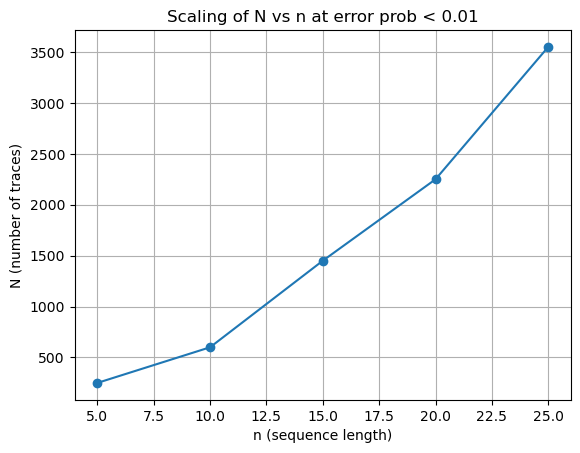

In [27]:
import matplotlib.pyplot as plt

n = [5, 10, 15, 20, 25]
N = [250, 600, 1450, 2250, 3550]

plt.plot(n, N, marker='o')

plt.xlabel("n (sequence length)")
plt.ylabel("N (number of traces)")
plt.title("Scaling of N vs n at error prob < 0.01")

plt.grid(True)
plt.show()

In [83]:
import csv

channels = {
    'W1': channel_W1,
    'W2': channel_W2,
    'W3': channel_W3
}

n_values = [5, 10, 15, 20, 25]
results = []

for channel_name, channel_func in channels.items():
    for n in n_values:
        for N in range(50, 5000, 50):
            err = estimate_error_prob(n, N, channel_func,estimate_x_bitwise, trials=500)
            
            if err < 0.01:
                results.append({
                    'Channel': channel_name,
                    'n': n,
                    'N': N,
                    'Error': err
                })
                print(f"Channel {channel_name}, n={n}: Found N={N}, Error={err:.4f}")
                break

# Save to CSV
with open('channel_results_bitwise.csv', 'a', newline='') as csvfile:
    fieldnames = ['Channel', 'n', 'N', 'Error']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    writer.writerows(results)
    

print("\nResults saved to channel_results_bitwise.csv")
print(results)

Channel W1, n=5: Found N=250, Error=0.0000
Channel W1, n=10: Found N=700, Error=0.0040
Channel W1, n=15: Found N=1150, Error=0.0080
Channel W1, n=20: Found N=2250, Error=0.0080
Channel W1, n=25: Found N=3100, Error=0.0040
Channel W2, n=5: Found N=100, Error=0.0000
Channel W2, n=10: Found N=150, Error=0.0060
Channel W2, n=15: Found N=400, Error=0.0060
Channel W2, n=20: Found N=600, Error=0.0080
Channel W2, n=25: Found N=1050, Error=0.0040
Channel W3, n=5: Found N=150, Error=0.0040
Channel W3, n=10: Found N=350, Error=0.0020
Channel W3, n=15: Found N=650, Error=0.0080
Channel W3, n=20: Found N=950, Error=0.0080
Channel W3, n=25: Found N=1700, Error=0.0060

Results saved to channel_results_bitwise.csv
[{'Channel': 'W1', 'n': 5, 'N': 250, 'Error': 0.0}, {'Channel': 'W1', 'n': 10, 'N': 700, 'Error': 0.004}, {'Channel': 'W1', 'n': 15, 'N': 1150, 'Error': 0.008}, {'Channel': 'W1', 'n': 20, 'N': 2250, 'Error': 0.008}, {'Channel': 'W1', 'n': 25, 'N': 3100, 'Error': 0.004}, {'Channel': 'W2', 'n'

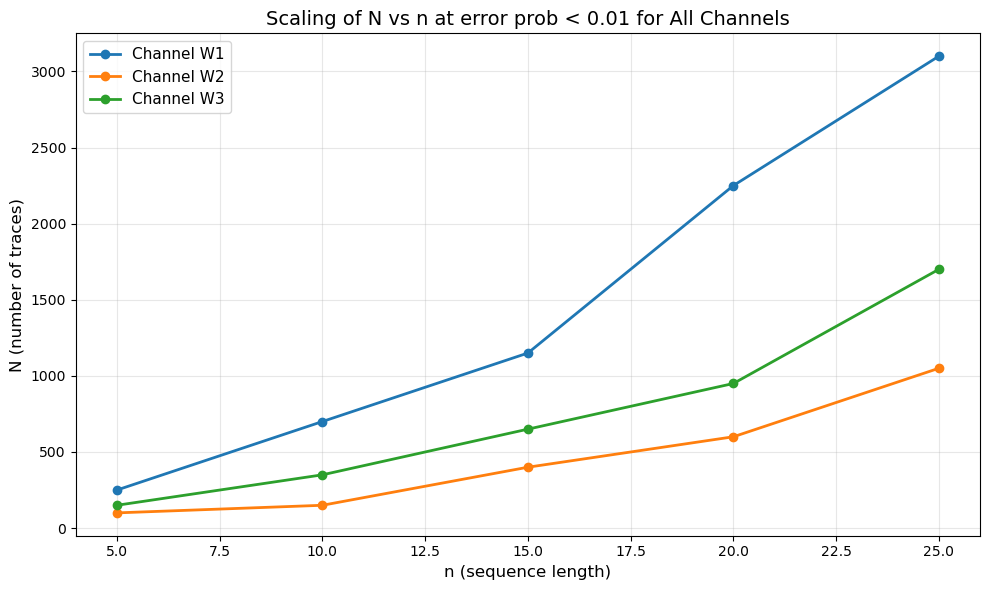

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV file
df = pd.read_csv('channel_results_bitwise.csv')

# Create plot
plt.figure(figsize=(10, 6))

# Plot each channel
for channel in df['Channel'].unique():
    channel_data = df[df['Channel'] == channel].sort_values('n')
    plt.plot(channel_data['n'], channel_data['N'], marker='o', label=f'Channel {channel}', linewidth=2)

plt.xlabel('n (sequence length)', fontsize=12)
plt.ylabel('N (number of traces)', fontsize=12)
plt.title('Scaling of N vs n at error prob < 0.01 for All Channels', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
import csv

channels = {
    # 'W1': channel_W1,
    # 'W2': channel_W2
    'W3': channel_W3
}

n= 20
results = []
delta_values = [0.01, 0.02, 0.03, 0.04, 0.05]

for channel_name, channel_func in channels.items():
    for delta in delta_values:
        for N in range(50, 5000, 10):
            err = estimate_error_prob(n, N, channel_func,estimate_x_pfm, trials=500)
            print(f"Channel {channel_name}, n={n}, delta={delta}: Testing N={N}, Error={err:.4f}")
            if err <= delta:
                results.append({
                    'Channel': channel_name,
                    'n': n,
                    'Delta': delta,
                    'N': N,
                    'Error': err
                })
                print(f"Channel {channel_name}, n={n}: Found N={N}, Error={err:.4f}")
                break

# Save to CSV
with open('channel_results_pfm.csv', 'a', newline='') as csvfile:
    fieldnames = ['Channel', 'n', 'Delta', 'N', 'Error']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    writer.writerows(results)

print("\nResults saved to channel_results_pfm.csv")
print(results)

Channel W3, n=20, delta=0.01: Testing N=50, Error=0.2440
Channel W3, n=20, delta=0.01: Testing N=60, Error=0.1940
Channel W3, n=20, delta=0.01: Testing N=70, Error=0.1880
Channel W3, n=20, delta=0.01: Testing N=80, Error=0.1620
Channel W3, n=20, delta=0.01: Testing N=90, Error=0.1040
Channel W3, n=20, delta=0.01: Testing N=100, Error=0.0960
Channel W3, n=20, delta=0.01: Testing N=110, Error=0.0920
Channel W3, n=20, delta=0.01: Testing N=120, Error=0.0880
Channel W3, n=20, delta=0.01: Testing N=130, Error=0.0700
Channel W3, n=20, delta=0.01: Testing N=140, Error=0.0720
Channel W3, n=20, delta=0.01: Testing N=150, Error=0.0400
Channel W3, n=20, delta=0.01: Testing N=160, Error=0.0660
Channel W3, n=20, delta=0.01: Testing N=170, Error=0.0360
Channel W3, n=20, delta=0.01: Testing N=180, Error=0.0400
Channel W3, n=20, delta=0.01: Testing N=190, Error=0.0340
Channel W3, n=20, delta=0.01: Testing N=200, Error=0.0300
Channel W3, n=20, delta=0.01: Testing N=210, Error=0.0380
Channel W3, n=20, d

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV file
def plottesh(filename):
    df = pd.read_csv(filename)

    # Create plot
    plt.figure(figsize=(12, 7))

    # Plot each channel
    for channel in df['Channel'].unique():
        channel_data = df[df['Channel'] == channel].sort_values('Delta')
        plt.plot(channel_data['Delta'], channel_data['N'], marker='o', label=f'Channel {channel}', linewidth=2, markersize=8)

    plt.xlabel('Delta (error threshold)', fontsize=12)
    plt.ylabel('N (number of traces)', fontsize=12)
    plt.title('Required N vs Delta (error threshold) for n=20', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plottesh('channel_results_pfm.csv')

KeyError: 'Delta'

<Figure size 1200x700 with 0 Axes>

## Maximum Likelihood

In [14]:
def common_prefix_length(s1, s2):
    length = 0
    for i in range(min(len(s1), len(s2))):
        if s1[i] == s2[i]:
            length += 1
        else:
            break
    return length

def maximum_likelihood(inp, N, n, q=2, channel_func=channel_W1):
    traces = generate_traces(inp, N, channel_func, q)
    max_likelihood = -1
    best_candidate = None
    total_candidates = q ** n
    last_progress = 0
    
    for candidate in range(total_candidates):
        # Progress tracking at 10% intervals
        progress = int((candidate / total_candidates) * 100)
        if progress >= last_progress + 10:
            # print(f"Progress: {progress}% done ({candidate}/{total_candidates})")
            last_progress = progress
        
        candidate_bits = np.array(list(np.base_repr(candidate, base=q).zfill(n)), dtype=int)
        log_likelihood = 0
        for t in traces:
            prefix_len = common_prefix_length(candidate_bits, t)
            log_likelihood += np.log(q**(prefix_len+1)-1)
            # log_likelihood += prefix_len+1
            
        
        if best_candidate is None or log_likelihood > max_likelihood:
            best_candidate = candidate_bits
            max_likelihood = log_likelihood
    
    # print(f"Progress: 100% done")
    return best_candidate, max_likelihood


In [15]:
def estimate_error_prob_ml(n, N, channel_func,q=2,trials=1000):
  errors = 0

  for _ in range(trials):
      X = np.random.randint(0, q, size=n)
      X_hat, _ = maximum_likelihood(X, N, n,q,channel_func)

      if not np.array_equal(X, X_hat):
          errors += 1

  return errors / trials

In [ ]:
import csv

channels = {
    'W1': channel_W1,
    'W2': channel_W2
    # 'W3': channel_W3
}

n_values = [14, 16,18, 20, 24]

# Open CSV file and write header
with open('channel_results_ml.csv', 'w', newline='') as csvfile:
    fieldnames = ['Channel', 'n', 'N', 'Error']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()

# Write results as they are found
with open('channel_results_ml.csv', 'a', newline='') as csvfile:
    fieldnames = ['Channel', 'n', 'N', 'Error']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    for channel_name, channel_func in channels.items():
        for n in n_values:
            for N in range(50, 5000, 40):
                err = estimate_error_prob_ml(n, N, channel_func,q=2,trials=500)
                print(f"n={n}, N={N}, Error={err:.4f}\n\n")
                if err < 0.01:
                    result = {
                        'Channel': channel_name,
                        'n': n,
                        'N': N,
                        'Error': err
                    }
                    writer.writerow(result)
                    csvfile.flush()  # Flush to disk immediately
                    print(f"Channel {channel_name}, n={n}: Found N={N}, Error={err:.4f}")
                    break

print("\nResults saved to channel_results_ml.csv")


## Taking Large values of n

In [ ]:
import csv

channels = {
    # 'W1': channel_W1,
    # 'W2': channel_W2
    'W3': channel_W3
}

n_values = range(50,1050,50)
results = []

for channel_name, channel_func in channels.items():
    for n in n_values:
        for N in range(500, 50000, 50):
            err = estimate_error_prob(n, N, channel_func,estimate_x_bitwise, trials=500)
            print(f"Channel {channel_name}, n={n}: N={N}, Error={err:.4f}")
            
            if err < 0.01:
                results.append({
                    'Channel': channel_name,
                    'n': n,
                    'N': N,
                    'Error': err
                })
                print(f"Found N={N} for Channel {channel_name}, n={n}: Error={err:.4f}")
                break

# Save to CSV
with open('channel_results_largen.csv', 'w', newline='') as csvfile:
    fieldnames = ['Channel', 'n', 'N', 'Error']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    writer.writerows(results)

print("\nResults saved to channel_results_largen.csv")
print(results)

Channel W1, n=50: N=500, Error=0.5340
Channel W1, n=50: N=550, Error=0.5300
Channel W1, n=50: N=600, Error=0.4820
Channel W1, n=50: N=650, Error=0.5080
Channel W1, n=50: N=700, Error=0.4420
Channel W1, n=50: N=750, Error=0.4900
Channel W1, n=50: N=800, Error=0.4300
Channel W1, n=50: N=850, Error=0.4060
Channel W1, n=50: N=900, Error=0.4000
Channel W1, n=50: N=950, Error=0.3680
Channel W1, n=50: N=1000, Error=0.3660
Channel W1, n=50: N=1050, Error=0.3680
Channel W1, n=50: N=1100, Error=0.3420
Channel W1, n=50: N=1150, Error=0.3360
Channel W1, n=50: N=1200, Error=0.3200
Channel W1, n=50: N=1250, Error=0.3340
Channel W1, n=50: N=1300, Error=0.3240
Channel W1, n=50: N=1350, Error=0.3300
Channel W1, n=50: N=1400, Error=0.3080
Channel W1, n=50: N=1450, Error=0.3440
Channel W1, n=50: N=1500, Error=0.2900
Channel W1, n=50: N=1550, Error=0.2880
Channel W1, n=50: N=1600, Error=0.2780
Channel W1, n=50: N=1650, Error=0.2800
Channel W1, n=50: N=1700, Error=0.2300
Channel W1, n=50: N=1750, Error=0.2

KeyboardInterrupt: 

Found N=11300 for Channel W1, n=50: Error=0.0080